In [1]:
# Import libraries and setup matplotlib defaults
from matplotlib import pyplot as pl
import pandas as pd
import numpy as np
pl.style.use('bmh')
clist = ['#377eb8', '#e41a1c', '#4daf4a', '#984ea3', '#ff7f00',
         '#ffff33', '#a65628', '#f781bf', '#999999']
prop_cycle = pl.cycler(color=clist)
pl.rcParams.update({
    'axes.prop_cycle': prop_cycle,
    'lines.linewidth': 2,
    'font.size': 20,
    'figure.figsize': [12, 8],
    'figure.subplot.left': 0.125,
    'figure.subplot.right': 0.95,
    'figure.subplot.bottom': 0.15})

In [2]:
import sys
sys.path.append('../')
from data_utils import *

md = load_membership_data()
td_raw = load_temple_data()

# deal with cases where no groundbreaking is listed, because groundbreaking date is used later
td = td_raw.copy()
missing_gr = td['Groundbreaking date'].isna() & ~td['Dedication date'].isna()
td.loc[missing_gr, 'Groundbreaking date'] = td[missing_gr]['Dedication date'] - np.timedelta64(3*365, 'D')

# for this analysis, exclude temple temples that won't be built
exclude = ['Efforts halted in 1830s', 'Efforts suspended in 2006', 'Historic site', 'Destroyed']
td = td[~td['Status'].isin(exclude)]

In [3]:
most_common_size_count = td.value_counts('area').iloc[0]

# Area categories
td['area_cat'] = ''
td.loc[td['area']>0, 'area_cat'] = '0-12000'
td.loc[td['area']>12000, 'area_cat'] = '12000-20000'
td.loc[td['area']>20000, 'area_cat'] = '20000-30000'
td.loc[td['area']>30000, 'area_cat'] = '30000-40000'
td.loc[td['area']>40000, 'area_cat'] = '40000-50000'
td.loc[td['area']>50000, 'area_cat'] = '50000-70000'
td.loc[td['area']>70000, 'area_cat'] = '70000-100000'
td.loc[td['area']>100000, 'area_cat'] = '100000+'

# Dedication decade
td['ded_dec'] = 'future'
td.loc[td['Dedication date'].dt.year>0, 'ded_dec'] = 'earlier'
td.loc[td['Dedication date'].dt.year>=1980, 'ded_dec'] = '1980s'
td.loc[td['Dedication date'].dt.year>=1990, 'ded_dec'] = '1990s'
td.loc[td['Dedication date'].dt.year>=2000, 'ded_dec'] = '2000s'
td.loc[td['Dedication date'].dt.year>=2010, 'ded_dec'] = '2010s'
td.loc[td['Dedication date'].dt.year>=2020, 'ded_dec'] = '2020s'

# region categories
td['reg_cat'] = 'non-US'
td.loc[td['Country']=='United States', 'reg_cat'] = 'other US'
td.loc[td['Region'].isin(['Utah', 'Idaho', 'Arizona']), 'reg_cat'] = 'UT/ID/AZ'

#td['area_cat'].value_counts().sort_index()
#td.value_counts('ded_dec').sort_index()
#td['reg2'].value_counts()

In [4]:
# For projecting future costs, estimate sizes of announced temples. Small, medium, and large
# temples are assigned to be 10,000, 20,000, and 30,000 square feet. Most of the temples are
# presumed to be small, including all of those in Europe and Asia. A few are presumed medium
# based on being near large population centers in countries with large church membership.
small_temple_list = [
    'Campo Grande Brazil Temple',
    'Porto Portugal Temple',
    'Uyo Nigeria Temple',
    'San Jose Del Monte Philippines Temple',
    'Nouméa New Caledonia Temple',
    'Liverpool Australia Temple',
    'Caldwell Idaho Temple',
    'Flagstaff Arizona Temple',
    'Rapid City South Dakota Temple',
    'Alabang Philippines Temple',
    'Puerto Montt Chile Temple',
    'Dublin Ireland Temple',
    'Milan Italy Temple',
    "Coeur d'Alene Idaho Temple",
    'Queen Creek Arizona Temple',
    'Rosario Argentina Temple',
    'Maracaibo Venezuela Temple',
    'Dubai United Arab Emirates Temple',
    'Retalhuleu Guatemala Temple',
    'Iloilo Philippines Temple',
    'Cape Coast Ghana Temple',
    'Calabar Nigeria Temple',
    'Luanda Angola Temple',
    'Mbuji-Mayi Democratic Republic of the Congo Temple',
    'Beira Mozambique Temple',
    'Monrovia Liberia Temple',
    'Busan Korea Temple',
    'Naga Philippines Temple',
    'Piura Peru Temple',
    'Huancayo Peru Temple',
    'Santiago Philippines Temple',
    'Chiclayo Peru Temple',
    'Buenos Aires City Center Argentina Temple',
    'Laoag Philippines Temple',
    'Tula Mexico Temple',
    'Roanoke Virginia Temple',
    'Cancún Mexico Temple',
    'Pachuca Mexico Temple',
    'Rosario Argentina Temple'
    'Singapore Republic of Singapore Temple',
    'Uturoa French Polynesia Temple',
    'Santa Ana El Salvador Temple',
    'Abuja Nigeria Temple',
    'Kampala Uganda Temple',
    'Reynosa Mexico Temple',
    'Chorrillos Peru Temple',
    'Rivera Uruguay Temple',
    'Maputo Mozambique Temple',
    'Edinburgh Scotland Temple']

medium_temple_list = [
    'El Paso Texas Temple',
    'Huntsville Alabama Temple',
    'Milwaukee Wisconsin Temple',
    'Summit New Jersey Temple',
    'Price Utah Temple',
    'Juchitan de Zaragoza Mexico Temple',
    'Medellín Colombia Temple',
    'Santiago Dominican Republic Temple',
    'Greenville South Carolina Temple',
    'Brisbane Australia South Temple',
    'Victoria British Columbia Temple',
    'Yuma Arizona Temple',
    'Kahului Hawaii Temple',
    'Honolulu Hawaii Temple',
    'Hamburg Germany Temple',
    'Goiânia Brazil Temple',
    'Norfolk Virginia Temple',
    'Florianópolis Brazil Temple']

large_temple_list = [
    'Houston Texas South Temple',
    'Prosper Texas Temple',
    'Spanish Fork Utah Temple']

even_larger_list = []

who_knows_if_it_will_get_built_list = [
    'Russia Temple',
    "Shanghai People's Republic of China Temple"]

# Check whether items need to be added or removed
combined_list = small_temple_list+medium_temple_list+large_temple_list+even_larger_list+ \
            who_knows_if_it_will_get_built_list
no_area = td['area'].isna()
in_lists = td['Name'].isin(combined_list)
to_add_to_lists = td[no_area & ~in_lists]['Name'].to_list()
to_remove_from_lists = td[in_lists & ~no_area]['Name'].to_list()

if len(to_add_to_lists):
    print('need to add to lists:')
    print(to_add_to_lists)

if len(to_remove_from_lists):
    print('need to remove from lists:')
    print(to_remove_from_lists)
    print(td[td['Name'].isin(to_remove_from_lists)][['Name', 'area']])


td.loc[td['Name'].isin(small_temple_list), 'area'] = 10000
td.loc[td['Name'].isin(medium_temple_list), 'area'] = 20000
td.loc[td['Name'].isin(large_temple_list), 'area'] = 30000
td.loc[td['Name'].isin(even_larger_list), 'area'] = 40000

td['area_estimated'] = 0
td.loc[td['Name'].isin(small_temple_list+medium_temple_list+large_temple_list), 'area_estimated'] = 1

# estimate site size for temples that don't have lots yet.
# based on previous averages, small:3 acres, medium: 6 acres, large: 10 acres
lot_dict = {10000:3, 20000:6, 30000:10, 40000:10}
site_idx = td['site'].isna() & ~td['area'].isna()

td[site_idx][['Name', 'area', 'Announcement date']]
td['site_estimated'] = 0
td.loc[site_idx, 'site_estimated'] = 1

td.loc[site_idx, 'site'] = td[site_idx]['area'].replace(lot_dict)

In [5]:
# Use temples completed since 2008 as a reference for estimating planning and construction time
# set minimum date for estimated grounbreaking and dedication so they aren't in the past
min_date = pd.to_datetime('2023-07-01')

ref_temples = td[(td['Announcement date'].dt.year>=2008) & (~td['Dedication date'].isna())]
est_times = ref_temples[['Announcement date', 'Groundbreaking date',
                         'Dedication date']].diff(axis=1).mean()

gr_est = td['Groundbreaking date'].isna()
td.loc[gr_est, 'Groundbreaking date'] = td[gr_est][
    'Announcement date'] + est_times['Groundbreaking date']
idx = gr_est & (td['Groundbreaking date'] < min_date)
td.loc[idx, 'Groundbreaking date'] = min_date

de_est = td['Dedication date'].isna()
td.loc[de_est, 'Dedication date'] = td[de_est][
    'Groundbreaking date'] + est_times['Dedication date']
idx = de_est & (td['Dedication date'] < min_date)
td.loc[idx, 'Dedication date'] = min_date

td['completion_estimated'] = 0
td.loc[de_est, 'completion_estimated'] = 1

In [6]:
# costs are per square foot and per acre
construction_cost = 1000
land_cost = 1000000

date_info = td[~td['Dedication date'].isna() & ~td['Groundbreaking date'].isna() &
               (td['Dedication date']>pd.to_datetime('1950-01-01'))][
    ['Groundbreaking date', 'Dedication date', 'area',
     'site', 'completion_estimated', 'site_estimated']]
date_info['land_purchase'] = date_info['Groundbreaking date'].dt.year - 1

date_info['years'] = date_info.apply(lambda x: range(x['Groundbreaking date'].year,
                                                     x['Dedication date'].year+1), axis=1)
date_info['area_amortized'] = date_info['area'] / date_info['years'].str.len()

years = date_info.explode('years')[['years', 'area_amortized', 'completion_estimated']]

yearly_total_ = years.groupby(['years', 'completion_estimated']).sum().reset_index().pivot(
    index='years', columns='completion_estimated').fillna(0)
yearly_total_.columns = ['area_amortized', 'area_amortized_est']

yearly_total = pd.Series(index=range(1950,2029), dtype='float64').to_frame('x').join(
    yearly_total_).drop(columns='x').fillna(0)

land_acres = date_info[['land_purchase', 'site', 'site_estimated']].groupby(
    ['land_purchase', 'site_estimated']).sum().reset_index().pivot(
    index='land_purchase', columns='site_estimated').fillna(0)
land_acres.columns = ['land', 'land_est']

yearly_total = yearly_total.join(land_acres).fillna(0)
yearly_total['land cost'] = yearly_total['land']*land_cost
yearly_total['land cost (projected)'] = yearly_total['land_est']*land_cost
yearly_total['construction cost'] = yearly_total['area_amortized']*construction_cost
yearly_total['construction cost (projected)'] = yearly_total[
    'area_amortized_est']*construction_cost
yearly_total['total cost'] = yearly_total[['land cost', 'land cost (projected)',
                                           'construction cost',
                                           'construction cost (projected)']].sum(1)

I have twice previously posted analyses of data on temple construction ([1](https://qhspencer.github.io/lds-data-analysis/temples/), [2](https://qhspencer.github.io/lds-data-analysis/temples2/)). With the recent death of President Russell Nelson, who announced an unprecedented number of temples, and the announcement in the recent general conference that no further temples would be announced at this time because of the large backlog of announced temples, it is clear that this is the end of an era. The charts here are updates to the previous analysis looking back at the Nelson era now that we are entering a new one.

The data for this come from the same [Wikipedia tables](https://en.wikipedia.org/wiki/Comparison_of_temples_of_The_Church_of_Jesus_Christ_of_Latter-day_Saints) as before. I will not focus on the cost projections as much, because my prevoiusly projected peaks in construction costs may yet prove not to materialize given that the actual construction rate appears to have reached a limit, thus spreading the cost over more future years than I assumed previously.

The two areas of interest I will focus on here are the trends in temple space relative to membership, and trends in construction rates.

## Member/temple ratio
In the previous analyses, it was particularly instructive to look at total temple space relative to toal membership. I noted that prior surges in construction activity generally had the effect of maintaining the status quo, while the Nelson surge is having the effect of reducing the number of members per temple area to lower levels not seen in decades. An updated plot of this can be seen below.

In [7]:
area_time = td[['Dedication date','area']].sort_values('Dedication date')
area_time['total area (million sq ft)'] = area_time['area'].cumsum()/1e6
area_time['number'] = area_time.reset_index().index+1

area_time['year'] = area_time['Dedication date'].dt.year
year_end_vals = area_time.groupby('year')[['total area (million sq ft)', 'number']].max()

ym_tmp = year_end_vals.merge(
    md, left_index=True, right_on='Year', how='outer').sort_values('Year')
ym_tmp['date'] = pd.to_datetime(ym_tmp['Year'].apply(lambda x: f'{x+1}-01-01'))
# worst case growth: 0
last_idx = ym_tmp['Membership'].idxmax()
last_mem_val = ym_tmp.loc[last_idx]['Membership']
ym_tmp.loc[last_idx:, 'Membership (min)'] = last_mem_val
# best case growth: last 20 years
ref_mem_vals = ym_tmp[ym_tmp['Year'].between(2000,2021)]['Membership']
growth_factor = np.mean(ref_mem_vals.values[1:]/ref_mem_vals.values[:-1])
proj_years = ym_tmp.loc[last_idx:]['Year']
proj_mem = (last_mem_val * growth_factor**(proj_years - proj_years.iloc[0])).round(0)
ym_tmp.loc[last_idx:, 'Membership (max)'] = proj_mem

ym = ym_tmp[ym_tmp['Year']>=1877].copy()
ym['area'] = ym['total area (million sq ft)'].ffill()*1e6
ym['number'] = ym['number'].ffill().astype(int)

In [8]:
m_t = ym[['Membership', 'Membership (min)', 'Membership (max)']].divide(ym['number'], 0)
m_t.index = ym['date']
m_t.columns = ['historical', 'projected (min)', 'projected (max)']

m_a = ym[['Membership', 'Membership (min)', 'Membership (max)']].divide(ym['area'], 0)
m_a.index = ym['date']
m_a.columns = ['historical', 'projected (min)', 'projected (max)']

In [9]:
# calculate how many temples were using filmed endowment presentation
ef = td[['Name', 'Dedication date']].copy()
#ef['Dedication']<'1950-01-01'
film_era = ef['Dedication date']>'1950-01-01'
ef.loc[film_era, 'film_start'] = ef[film_era]['Dedication date']

conversion_dates = [
    ['St. George Utah Temple', '1975-11-11'],
    ['Logan Utah Temple', '1979-03-13'],
    ['Manti Utah Temple', '2025-01-01'],
    ['Salt Lake Temple', '2025-01-01'],
    ['Laie Hawaii Temple', '1978-06-13'],
    ['Cardston Alberta Temple', '1991-03-22'], # rededication date, seems later than the others
    ['Mesa Arizona Temple', '1975-04-16'],
    ['Idaho Falls Idaho Temple', '1975-01-01'] # no exact date on this one
]

for temple, date in conversion_dates:
    ef.loc[ef['Name']==temple, 'film_start'] = date
ef = ef.sort_values('Dedication date')
ef['total'] = np.arange(len(ef)) + 1
ef['film'] = 0
for idx, row in ef.iterrows():
    ef.loc[idx, 'film'] = (ef.loc[:idx, 'film_start']<=row['Dedication date']).sum()
ef['film_frac'] = ef['film']/ef['total']
#ef.plot(x='Dedication date', y='film_frac')

In [10]:
bg_shade = '#d7d7e7'
kimball_temples = ('1983-01-01', '1987-01-01')
hinckley_temples = ('1999-01-01', '2002-01-01')
nelson_temples = ('2022-01-01', '2025-07-01')
filmed_endowment_transition = (ef[ef['film_frac']<=0.15].iloc[-1]['Dedication date'],
                               ef[ef['film_frac']>=0.9].iloc[0]['Dedication date'])

def dateinterp(dates, r):
    a, b = [np.datetime64(val) for val in dates]
    return a + (b-a)*r

def add_bg(ax, bg='fkh', text=True, yvals={}):
    y_pos = lambda y: np.inner(ax.get_ylim(), (1-y, y))
    y_vals = {key:y_pos(0.05) for key in ('f', 'k', 'h', 'n')}
    y_vals.update(yvals)

    if 'f' in bg:
        ax.axvspan(*filmed_endowment_transition, color='#d7f7d7')
        if text:
            ax.annotate('transition to\nfilmed\nendowment', ('1958-01-01', y_vals['f']),
                        size='x-small', ha='left', va='bottom')
    if 'k' in bg:
        ax.axvspan(*kimball_temples, color=bg_shade)
        if text:
            ax.annotate('Kimball surge',
                        (dateinterp(kimball_temples, 0.7), y_vals['k']),
                        size='x-small', ha='center', va='bottom', rotation=90)
    if 'h' in bg:
        ax.axvspan(*hinckley_temples, color=bg_shade)
        if text:
            ax.annotate('Hinckley surge',
                        (dateinterp(hinckley_temples, 0.7), y_vals['h']),
                        size='x-small', ha='center', va='bottom', rotation=90)
    if 'n' in bg:
        ax.axvspan(*nelson_temples, color=bg_shade, zorder=0)
        if text:
            ax.annotate('Nelson surge',
                        (dateinterp(nelson_temples, 0.7), y_vals['n']),
                        size='x-small', ha='right', va='bottom', rotation=90)

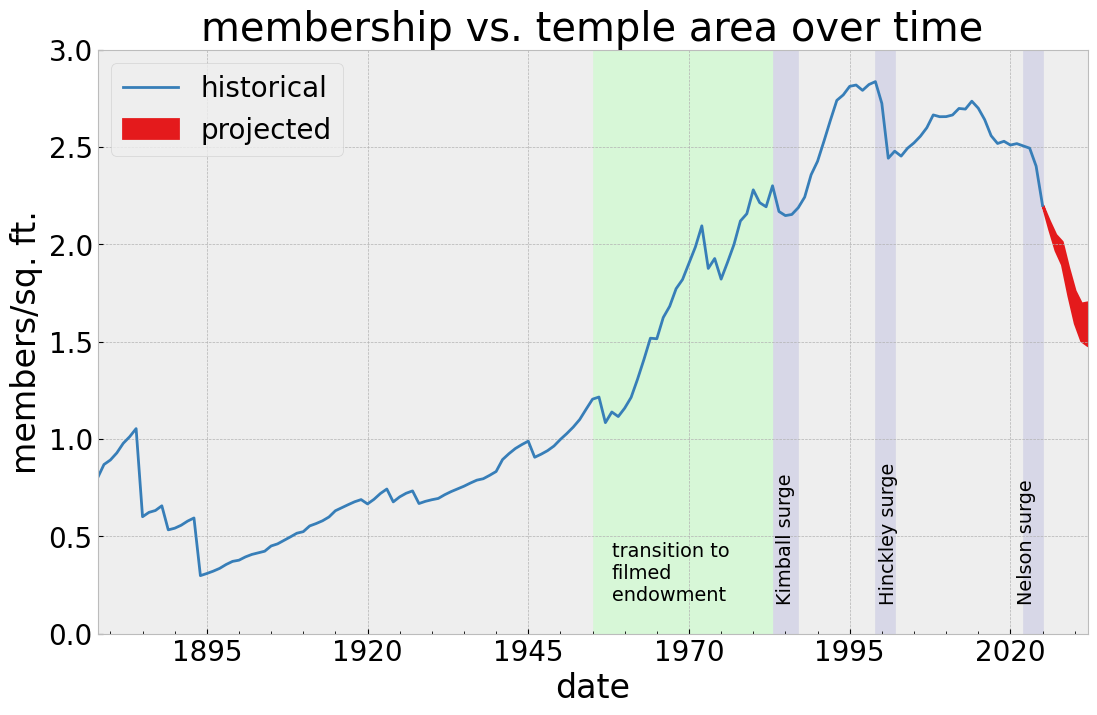

In [11]:
lw_default=2
#ax1 = m_t['historical'].plot(ylim=[0, None])
#ax1.fill_between(m_t.index, m_t['projected (min)'], m_t['projected (max)'],
#                 color=clist[1], lw=lw_default)
#ax1.legend(['historical', 'projected'], loc='upper left')
#add_bg(ax1, 'fkhn', yval=0.65)

pl.figure()
ax2 = m_a['historical'].plot(ylabel='members/sq. ft.', ylim=[0, 3],
                            title='membership vs. temple area over time')
ax2.fill_between(m_a.index, m_a['projected (min)'], m_a['projected (max)'],
                 color=clist[1], lw=lw_default)
ax2.legend(['historical', 'projected'], loc='upper left')
add_bg(ax2, 'fkhn')

While the space/membership ratio has begun to drop sharply in the last few years, if temple construction stopped now, we would still be at levels consistent with the filmed endowment era beginning around 1980. Projections are for that ratio to continue to fall sharply, but that ultimately depends on the rate at which the backlog of announced temples are built. The backlog analysis gives some clues about that.

## Construction progress
The chart below shows the annual rates of announcements, groundbreakings, and dedications. From the announcement data, it's clear that the Nelson presidency actually began with more modest numbers of temples announced, around 15 per year for 2018-2020. In the years 2021-2024, the rate more than doubled. Construction has not kept up, leaving a substantial backlog.

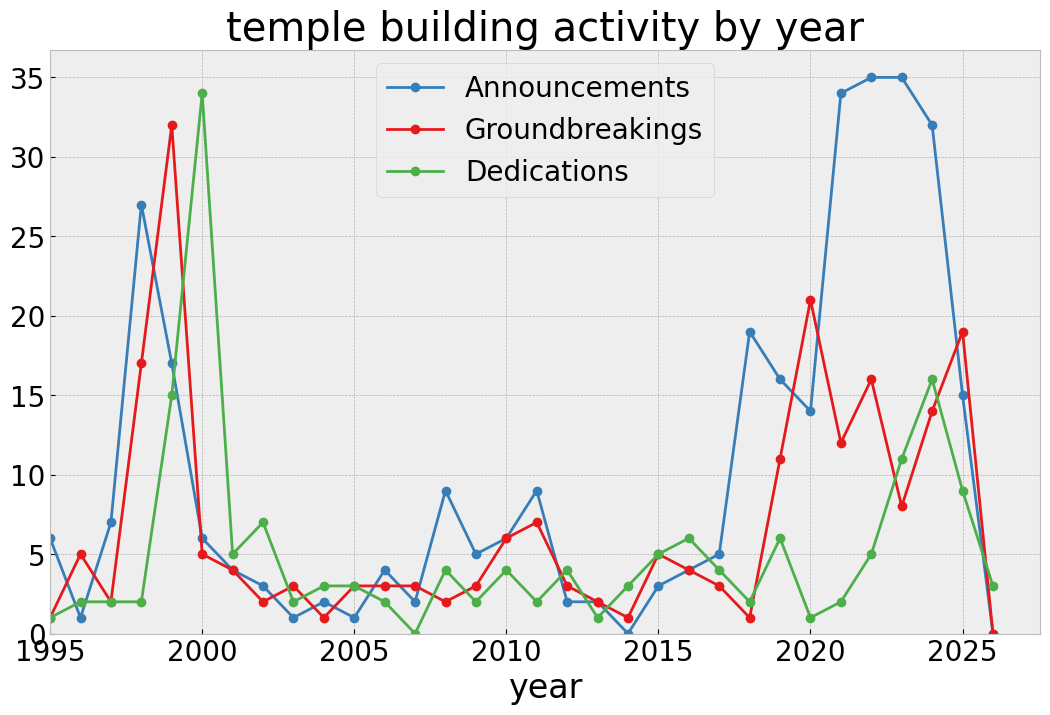

In [12]:
date_cols = ['Announcement date', 'Groundbreaking date', 'Dedication date']
activity_year = pd.DataFrame()
backlog = pd.DataFrame()
for yr in range(1995, 2027):
    backlog.loc[yr, 'planning'] = ((td_raw['Announcement date'] <= f'{yr}-12-31') &
                                   ((td_raw['Groundbreaking date'] > f'{yr}-12-31') |
                                    (td_raw['Groundbreaking date'].isna()))).sum()
    backlog.loc[yr, 'construction'] = ((td_raw['Groundbreaking date'] <= f'{yr}-12-31') &
                                       ((td_raw['Dedication date'] > f'{yr}-12-31') |
                                        (td_raw['Dedication date'].isna()))).sum()
    for c in date_cols:
        activity_year.loc[yr, c[:-5]+'s'] = (td_raw[c].dt.year==yr).sum()
backlog['total'] = backlog.sum(axis=1)

_ = activity_year.plot(xlim=[1995, None], ylim=[0, None], xlabel='year', marker='o',
                   title='temple building activity by year')

The chart below shows an updated backlog analysis. The "planning" and "construction" phases are determined by whether or not a groundbreaking has taken place. Since about 2022, the number under construction has remained steady at around 60 per year, and has not increased beyond that. That is a historically high rate of construction, easily exceeding the 1999 construction boom. It's clear that a maximum construction rate has been reached, whether imposed by constraints on budget or other resources. And yet, the continued new announcements have kept the planning phase group at roughly 120 since 2024.

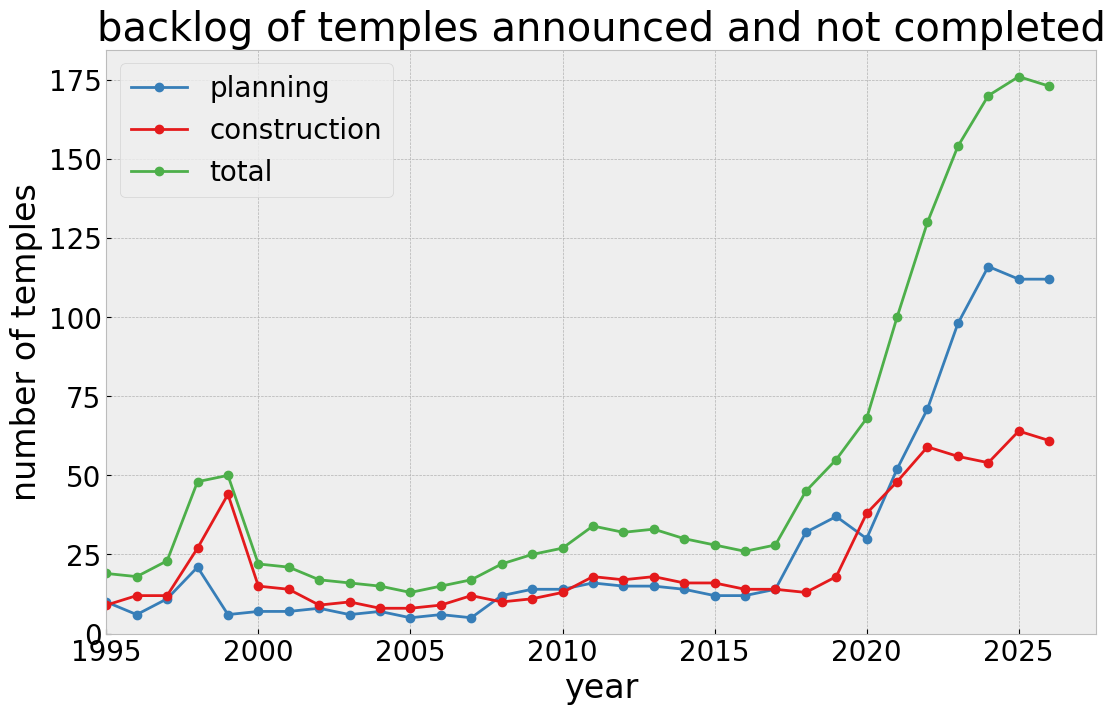

In [13]:
_ = backlog.plot(legend=True, marker='o',
                 ylim=[0, None], xlim=[1995, None],
                 xlabel='year', ylabel='number of temples',
                 title='backlog of temples announced and not completed')

# the future

The number of dedications per year since 2020 has been in the range of about 15-20 per year. If it's possible to complete 20 temples per year, the current backlog of nearly 170 temples in planning or construction phases will take over 8.5 years to complete, which would be the end of 2033. Historically, the number in planning phase and construction phase has been relatively balanced. Even if it were assumed that it is sustainable to have 60 temples under construction indefinitely into the future, to bring the planning stage group backlog down to a similar number would still require 3 years to partially clear the current backlog. Based on this, it is plausable that no new temples will be announced in 2026 and 2027, and possibly longer.

In [14]:
# Setup show/hide source code box
from IPython.display import HTML

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()">
<input type="submit" value="show/hide source code"></form>''')